# Notebook 08 — Q&A Testing

Tests both models on 15 hand-crafted translation pairs:
- 8 Modern → Shakespearean pairs
- 7 Shakespearean → Modern pairs

For each pair: show source, expected answer, LoRA output, FFT output, and sentence BLEU.

This is the qualitative "can the model answer translation questions" evaluation.

In [1]:
import sys
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import AutoPeftModelForCausalLM

sys.path.insert(0, str(Path('..').resolve()))
from src.inference import translate
from src.evaluation import sentence_bleu

ROOT      = Path('..').resolve()
QA_PATH   = ROOT / 'data' / 'qa_pairs' / 'test_qa_pairs.jsonl'
LORA_PATH = ROOT / 'outputs' / 'lora' / 'final_adapter'
FFT_PATH  = ROOT / 'outputs' / 'fft'  / 'final_model'
FIG_DIR   = ROOT / 'outputs' / 'results' / 'figures'

sns.set_theme(style='whitegrid')
print('Setup complete.')

Setup complete.


## 1. Load Q&A Pairs

In [2]:
with open(QA_PATH, encoding='utf-8') as f:
    qa_pairs = [json.loads(line) for line in f if line.strip()]

print(f'Loaded {len(qa_pairs)} Q&A pairs')
print(f'  Modern → Shakespeare: {sum(1 for q in qa_pairs if q["direction"] == "mod2shak")}')
print(f'  Shakespeare → Modern: {sum(1 for q in qa_pairs if q["direction"] == "shak2mod")}')
print()

# Display all pairs
for qa in qa_pairs:
    direction = 'Mod→Shak' if qa['direction'] == 'mod2shak' else 'Shak→Mod'
    print(f"[{qa['id']}] {direction}")
    print(f"  Source:   {qa['source']}")
    print(f"  Expected: {qa['expected']}")
    print()

Loaded 15 Q&A pairs
  Modern → Shakespeare: 8
  Shakespeare → Modern: 7

[m2s_01] Mod→Shak
  Source:   Where are you going?
  Expected: Whither dost thou go?

[m2s_02] Mod→Shak
  Source:   I love you more than words can say.
  Expected: I love thee more than words can wield the matter.

[m2s_03] Mod→Shak
  Source:   He has gone mad.
  Expected: He is mad as the vexed sea.

[m2s_04] Mod→Shak
  Source:   What is your name?
  Expected: What is thy name?

[m2s_05] Mod→Shak
  Source:   Good morning, my friend.
  Expected: Good morrow, good friend.

[m2s_06] Mod→Shak
  Source:   I cannot do this anymore.
  Expected: I can do it no more.

[m2s_07] Mod→Shak
  Source:   She is the most beautiful woman I have ever seen.
  Expected: She is the fairest creature mine eyes have beheld.

[m2s_08] Mod→Shak
  Source:   Be quiet and listen to me.
  Expected: Peace, and hear me speak.

[s2m_01] Shak→Mod
  Source:   Thou art the very pink of courtesy.
  Expected: You are the very model of politeness.

[s2

## 2. Load Both Models

In [3]:
print('Loading LoRA model ...')
model_lora = AutoPeftModelForCausalLM.from_pretrained(
    str(LORA_PATH), torch_dtype=torch.bfloat16, device_map='auto'
)
model_lora.eval()
tok_lora = AutoTokenizer.from_pretrained(str(LORA_PATH))
print('LoRA ready.')

print('Loading FFT model ...')
model_fft = AutoModelForCausalLM.from_pretrained(
    str(FFT_PATH), torch_dtype=torch.bfloat16, device_map='auto'
)
model_fft.eval()
tok_fft = AutoTokenizer.from_pretrained(str(FFT_PATH))
print('FFT ready.')

`torch_dtype` is deprecated! Use `dtype` instead!


Loading LoRA model ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

LoRA ready.
Loading FFT model ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

FFT ready.


## 3. Run Both Models on All Q&A Pairs

In [4]:
results = []

for qa in qa_pairs:
    direction = qa['direction']
    source    = qa['source']
    expected  = qa['expected']

    out_lora = translate(model_lora, tok_lora, source, direction=direction,
                         max_new_tokens=128, do_sample=False)
    out_fft  = translate(model_fft,  tok_fft,  source, direction=direction,
                         max_new_tokens=128, do_sample=False)

    lora_bleu = sentence_bleu(out_lora, expected)
    fft_bleu  = sentence_bleu(out_fft,  expected)

    results.append({
        'id':         qa['id'],
        'direction':  'Mod→Shak' if direction == 'mod2shak' else 'Shak→Mod',
        'source':     source,
        'expected':   expected,
        'lora_output': out_lora,
        'fft_output':  out_fft,
        'lora_bleu':  lora_bleu,
        'fft_bleu':   fft_bleu,
    })

print(f'Completed {len(results)} Q&A evaluations.')

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Completed 15 Q&A evaluations.


## 4. Results Table

In [5]:
df = pd.DataFrame(results)

print('=== Q&A Test Results ===\n')
for _, row in df.iterrows():
    print(f"[{row['id']}] {row['direction']}")
    print(f"  Source:      {row['source']}")
    print(f"  Expected:    {row['expected']}")
    print(f"  LoRA output: {row['lora_output']}  [BLEU: {row['lora_bleu']:.1f}]")
    print(f"  FFT output:  {row['fft_output']}   [BLEU: {row['fft_bleu']:.1f}]")
    print()

print('\n=== Numeric Summary ===')
summary = df[['id', 'direction', 'lora_bleu', 'fft_bleu']]
print(summary.to_string(index=False))
print(f'\nMean LoRA BLEU: {df["lora_bleu"].mean():.1f}')
print(f'Mean FFT BLEU:  {df["fft_bleu"].mean():.1f}')

=== Q&A Test Results ===

[m2s_01] Mod→Shak
  Source:      Where are you going?
  Expected:    Whither dost thou go?
  LoRA output: To seek my lord.  [BLEU: 0.0]
  FFT output:  I go to my chamber.   [BLEU: 8.1]

[m2s_02] Mod→Shak
  Source:      I love you more than words can say.
  Expected:    I love thee more than words can wield the matter.
  LoRA output: I am not worthy to be called a man if I do not love thee.  [BLEU: 5.8]
  FFT output:  I am glad to hear it.   [BLEU: 4.4]

[m2s_03] Mod→Shak
  Source:      He has gone mad.
  Expected:    He is mad as the vexed sea.
  LoRA output: Mad?  [BLEU: 0.0]
  FFT output:  I have heard him say he is a man that loves to be alone.   [BLEU: 3.1]

[m2s_04] Mod→Shak
  Source:      What is your name?
  Expected:    What is thy name?
  LoRA output: Iago.  [BLEU: 0.0]
  FFT output:  I am called Valentine.   [BLEU: 0.0]

[m2s_05] Mod→Shak
  Source:      Good morning, my friend.
  Expected:    Good morrow, good friend.
  LoRA output: How now?  [BLEU: 

## 5. Q&A BLEU Comparison Chart

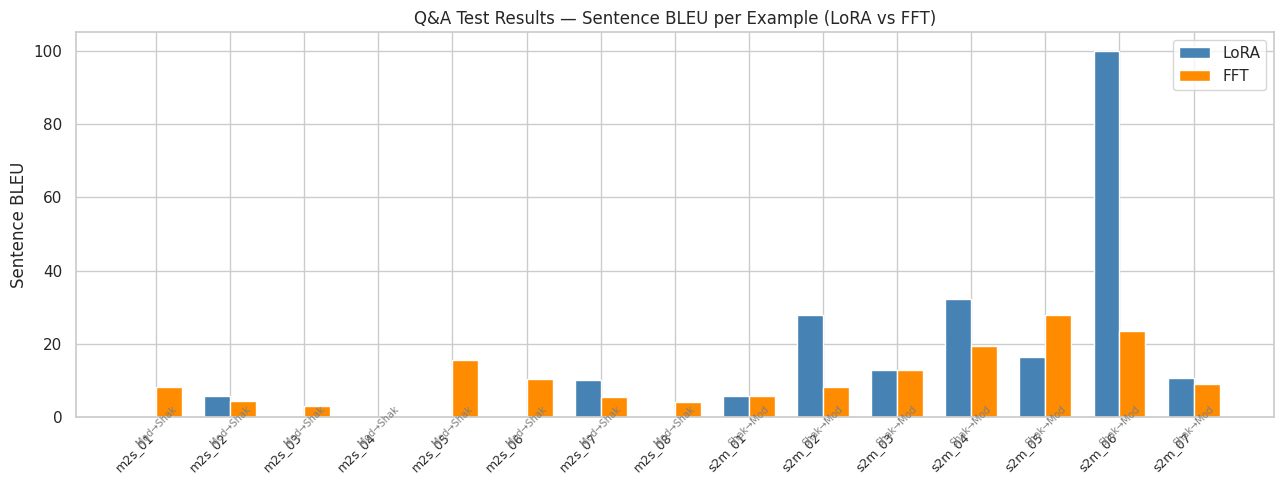

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

x     = np.arange(len(df))
width = 0.35

bars_lora = ax.bar(x - width/2, df['lora_bleu'], width, label='LoRA',
                   color='steelblue', edgecolor='white')
bars_fft  = ax.bar(x + width/2, df['fft_bleu'],  width, label='FFT',
                   color='darkorange', edgecolor='white')

# Color code by direction
colors = ['steelblue' if r == 'Mod→Shak' else 'lightsteelblue' for r in df['direction']]

ax.set_xticks(x)
ax.set_xticklabels(df['id'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Sentence BLEU')
ax.set_title('Q&A Test Results — Sentence BLEU per Example (LoRA vs FFT)')
ax.legend()
ax.set_ylim(0, 105)

# Add direction label above axis
for i, row in df.iterrows():
    ax.text(i, -8, row['direction'], ha='center', fontsize=7, color='gray', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / 'qa_bleu_per_example.png', dpi=150)
plt.show()

## 6. Save Results

In [7]:
df.to_csv(ROOT / 'outputs' / 'results' / 'qa_test_results.csv', index=False)
print('Q&A results saved to outputs/results/qa_test_results.csv')

# Summary by direction
print('\nMean BLEU by direction:')
print(df.groupby('direction')[['lora_bleu', 'fft_bleu']].mean().round(1).to_string())

Q&A results saved to outputs/results/qa_test_results.csv

Mean BLEU by direction:
           lora_bleu  fft_bleu
direction                     
Mod→Shak         2.0       6.4
Shak→Mod        29.4      15.3


In [8]:
import gc
del model_lora, model_fft
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Models unloaded. All evaluations complete.')

Models unloaded. All evaluations complete.
